<a href="https://www.kaggle.com/code/lalit7881/diabetes-dataset-eda?scriptVersionId=311395721" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/alihassankamal/diabetes-dataset/diabetes_prediction_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/alihassankamal/diabetes-dataset/diabetes_prediction_dataset.csv")

In [3]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [4]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [6]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [7]:
df.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(3854)

In [9]:
df.dtypes

gender                  object
age                    float64
hypertension             int64
heart_disease            int64
smoking_history         object
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

In [10]:
df.shape

(100000, 9)

In [11]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [12]:
df.nunique()

gender                    3
age                     102
hypertension              2
heart_disease             2
smoking_history           6
bmi                    4247
HbA1c_level              18
blood_glucose_level      18
diabetes                  2
dtype: int64

## EDA

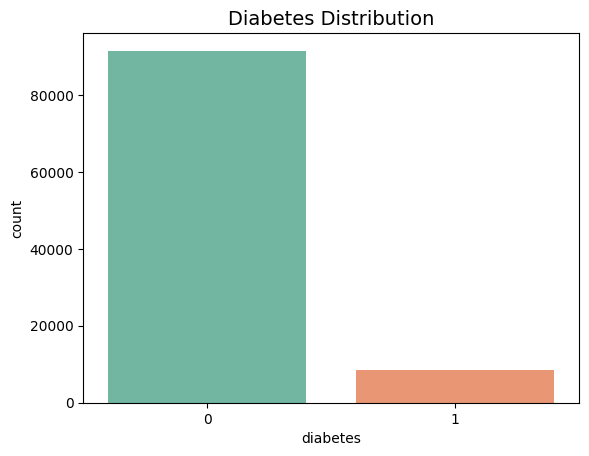

In [13]:
sns.countplot(x='diabetes', data=df, palette='Set2')
plt.title("Diabetes Distribution", fontsize=14)
plt.show()

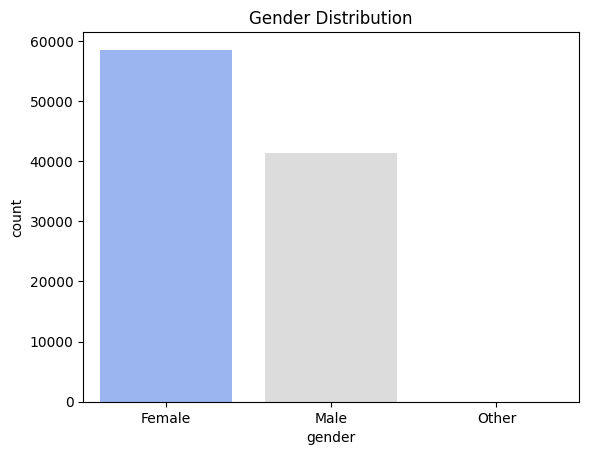

In [14]:
sns.countplot(x='gender', data=df, palette='coolwarm')
plt.title("Gender Distribution")
plt.show()

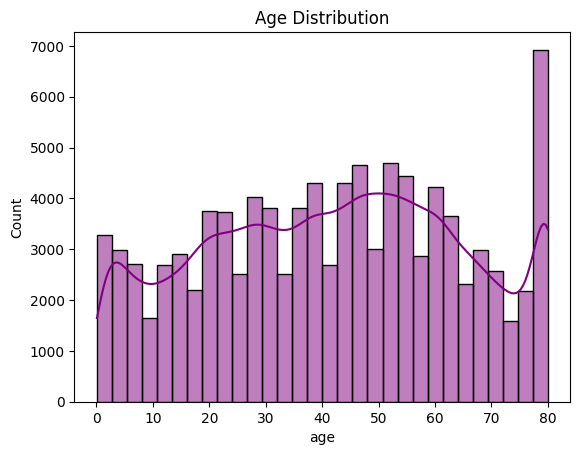

In [15]:
sns.histplot(df['age'], bins=30, kde=True, color='purple')
plt.title("Age Distribution")
plt.show()

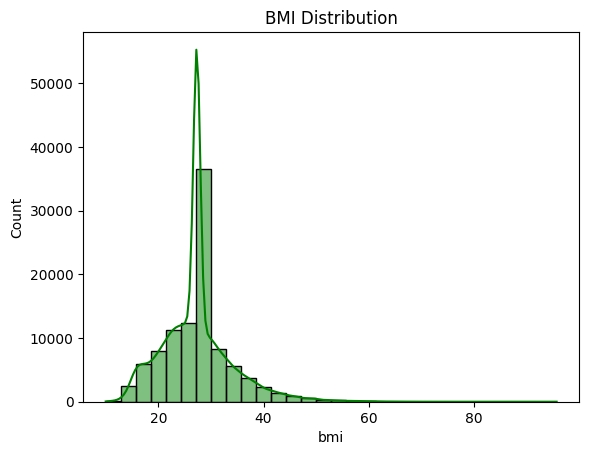

In [16]:
sns.histplot(df['bmi'], bins=30, kde=True, color='green')
plt.title("BMI Distribution")
plt.show()

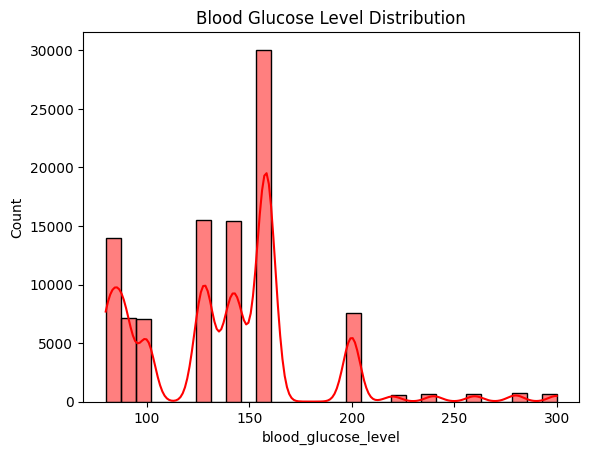

In [17]:
sns.histplot(df['blood_glucose_level'], bins=30, kde=True, color='red')
plt.title("Blood Glucose Level Distribution")
plt.show()

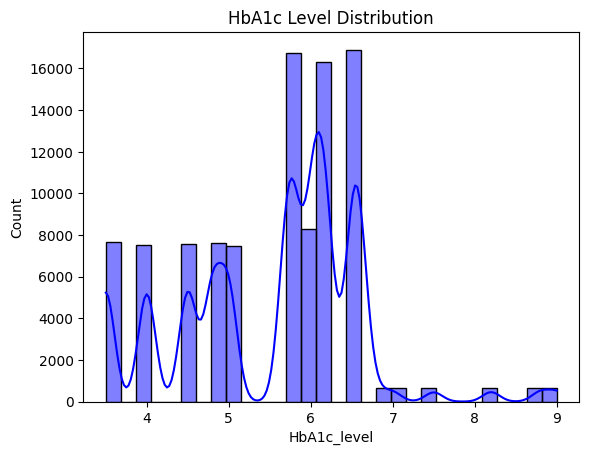

In [18]:
sns.histplot(df['HbA1c_level'], bins=30, kde=True, color='blue')
plt.title("HbA1c Level Distribution")
plt.show()

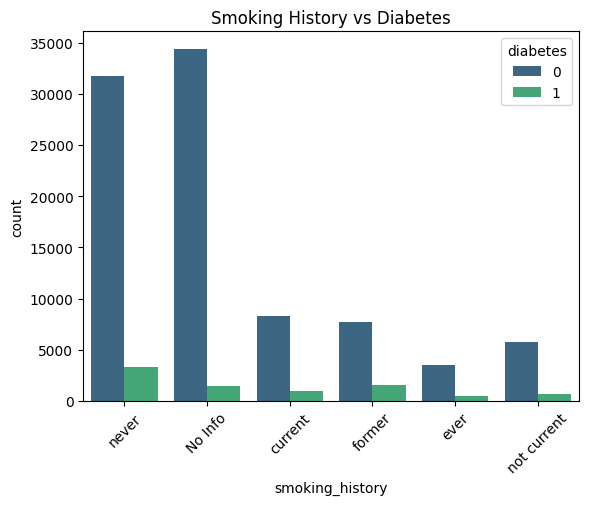

In [19]:
sns.countplot(x='smoking_history', hue='diabetes', data=df, palette='viridis')
plt.title("Smoking History vs Diabetes")
plt.xticks(rotation=45)
plt.show()

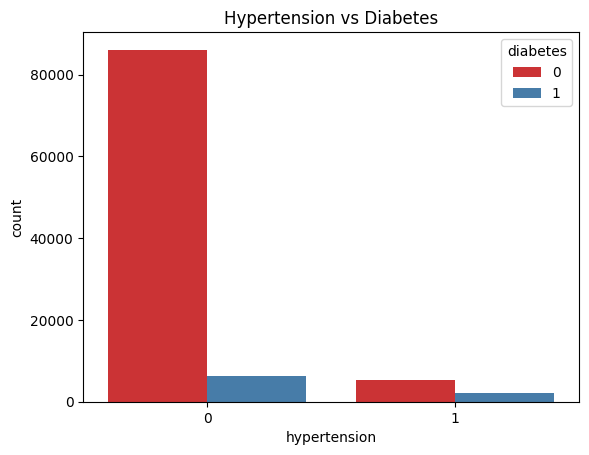

In [20]:
sns.countplot(x='hypertension', hue='diabetes', data=df, palette='Set1')
plt.title("Hypertension vs Diabetes")
plt.show()

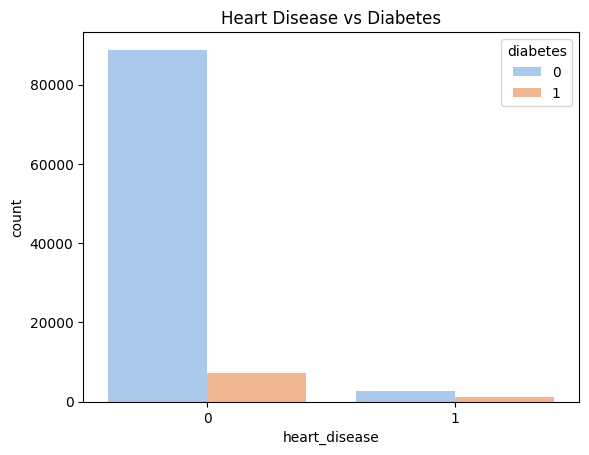

In [21]:
sns.countplot(x='heart_disease', hue='diabetes', data=df, palette='pastel')
plt.title("Heart Disease vs Diabetes")
plt.show()

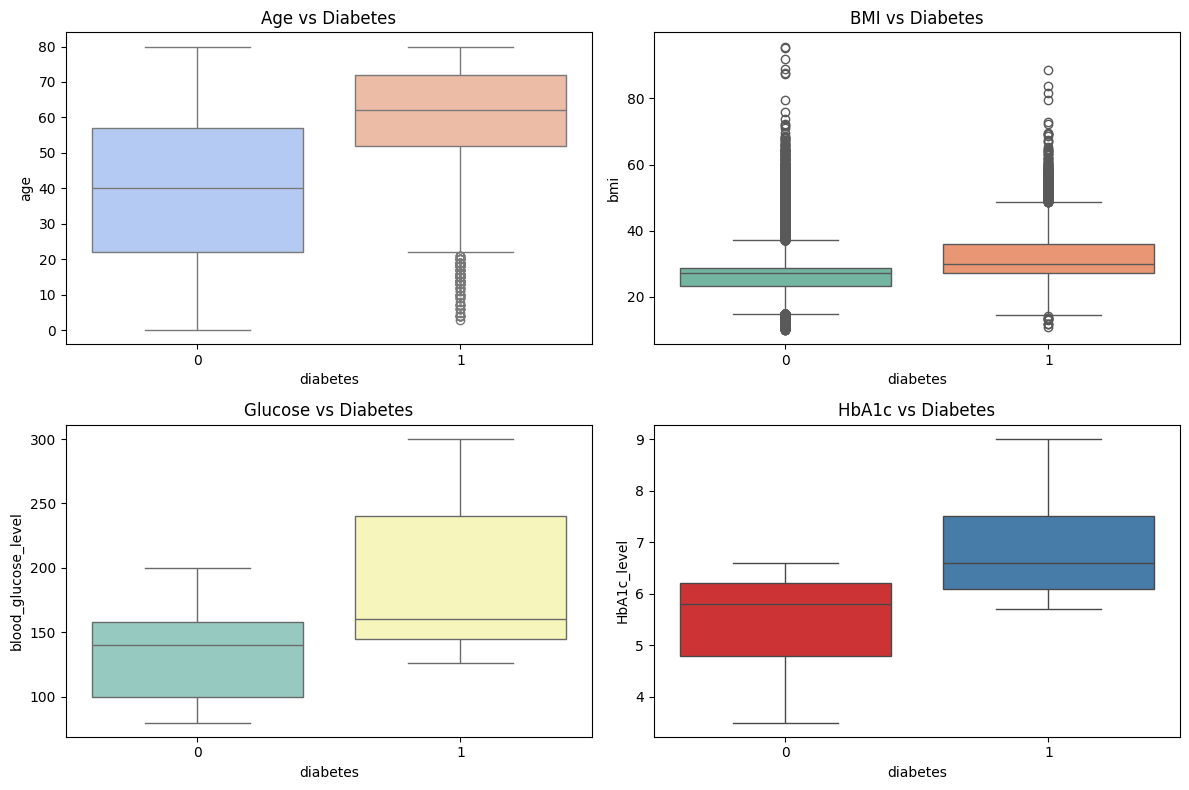

In [22]:
plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
sns.boxplot(x='diabetes', y='age', data=df, palette='coolwarm')
plt.title("Age vs Diabetes")

plt.subplot(2,2,2)
sns.boxplot(x='diabetes', y='bmi', data=df, palette='Set2')
plt.title("BMI vs Diabetes")

plt.subplot(2,2,3)
sns.boxplot(x='diabetes', y='blood_glucose_level', data=df, palette='Set3')
plt.title("Glucose vs Diabetes")

plt.subplot(2,2,4)
sns.boxplot(x='diabetes', y='HbA1c_level', data=df, palette='Set1')
plt.title("HbA1c vs Diabetes")

plt.tight_layout()
plt.show()

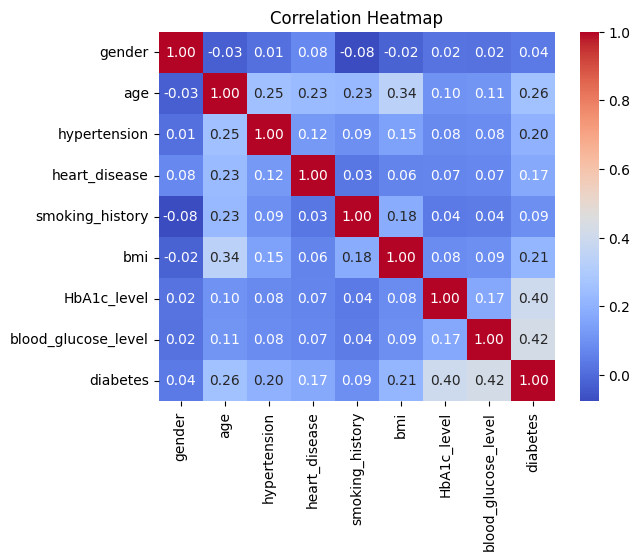

In [23]:
# Convert categorical to numeric (temporary for heatmap)
df_temp = df.copy()
df_temp['gender'] = df_temp['gender'].astype('category').cat.codes
df_temp['smoking_history'] = df_temp['smoking_history'].astype('category').cat.codes

corr = df_temp.corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

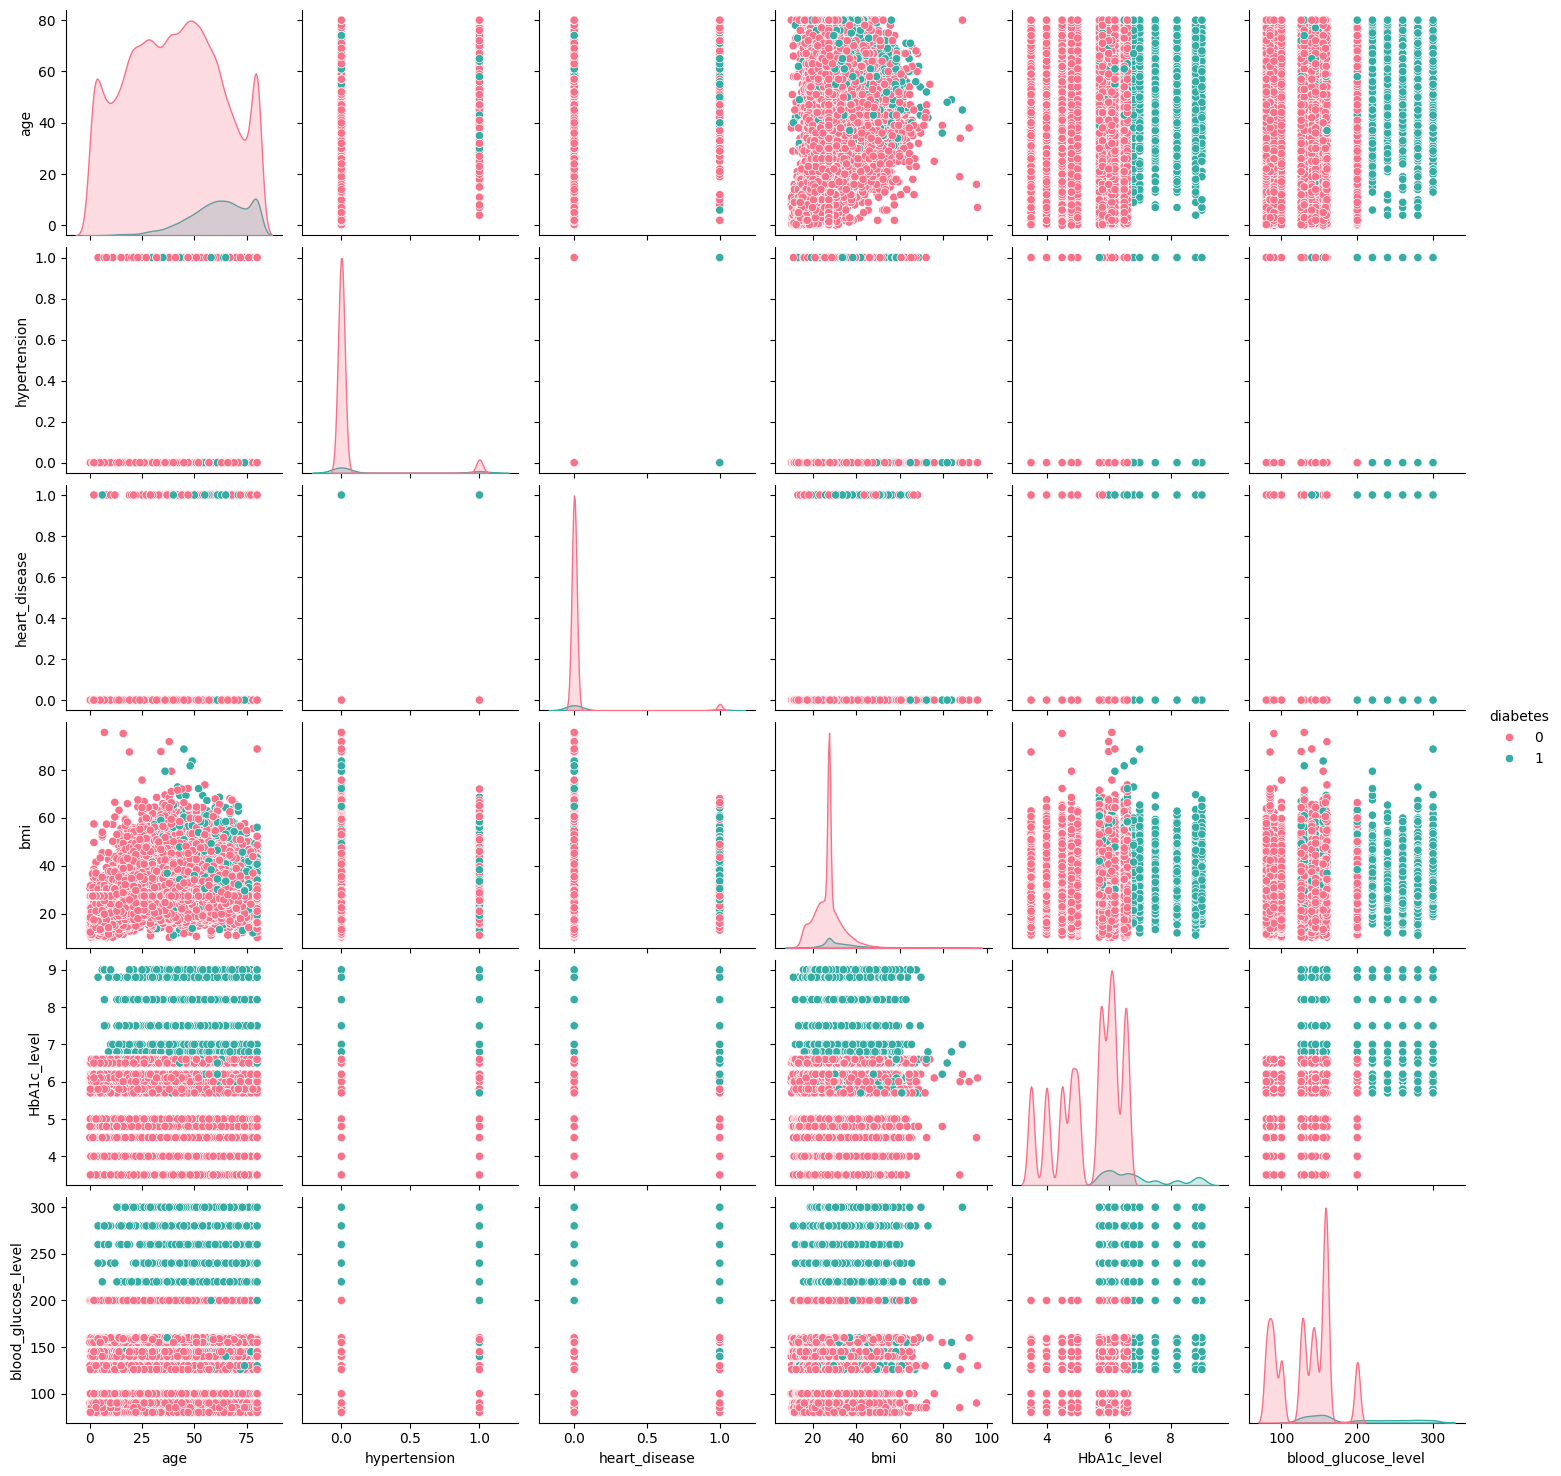

In [24]:
sns.pairplot(df, hue='diabetes', palette='husl')
plt.show()

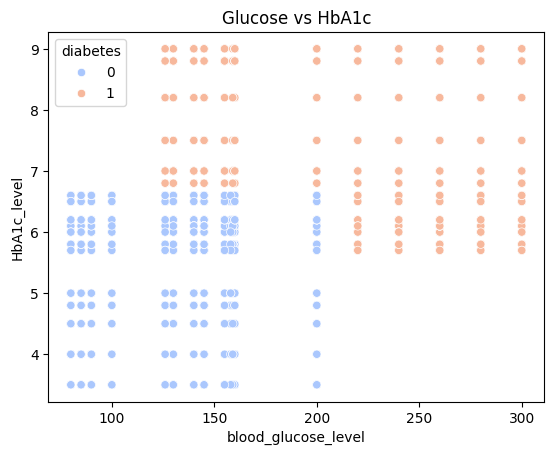

In [25]:
sns.scatterplot(x='blood_glucose_level', y='HbA1c_level', 
                hue='diabetes', palette='coolwarm', data=df)
plt.title("Glucose vs HbA1c")
plt.show()

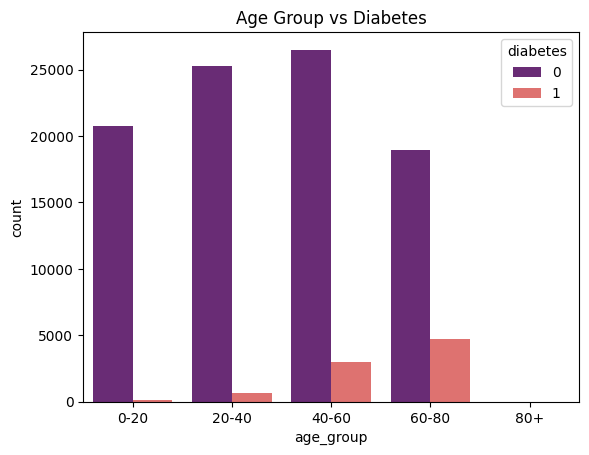

In [26]:
df['age_group'] = pd.cut(df['age'], bins=[0,20,40,60,80,100],
                         labels=['0-20','20-40','40-60','60-80','80+'])

sns.countplot(x='age_group', hue='diabetes', data=df, palette='magma')
plt.title("Age Group vs Diabetes")
plt.show()

## Feature engineering

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [28]:
# Drop unwanted column safely
df = df.drop(columns=['age_group'], errors='ignore')

In [29]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [31]:
cat_cols = ['gender', 'smoking_history']
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level', 
            'hypertension', 'heart_disease']


In [32]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [33]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}


================ Logistic Regression ================
Accuracy: 0.96045

Confusion Matrix:
 [[18121   179]
 [  612  1088]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.99      0.98     18300
           1       0.86      0.64      0.73      1700

    accuracy                           0.96     20000
   macro avg       0.91      0.82      0.86     20000
weighted avg       0.96      0.96      0.96     20000


================ Decision Tree ================
Accuracy: 0.9723

Confusion Matrix:
 [[18300     0]
 [  554  1146]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.99     18300
           1       1.00      0.67      0.81      1700

    accuracy                           0.97     20000
   macro avg       0.99      0.84      0.90     20000
weighted avg       0.97      0.97      0.97     20000


================ Random Forest ================
Accura

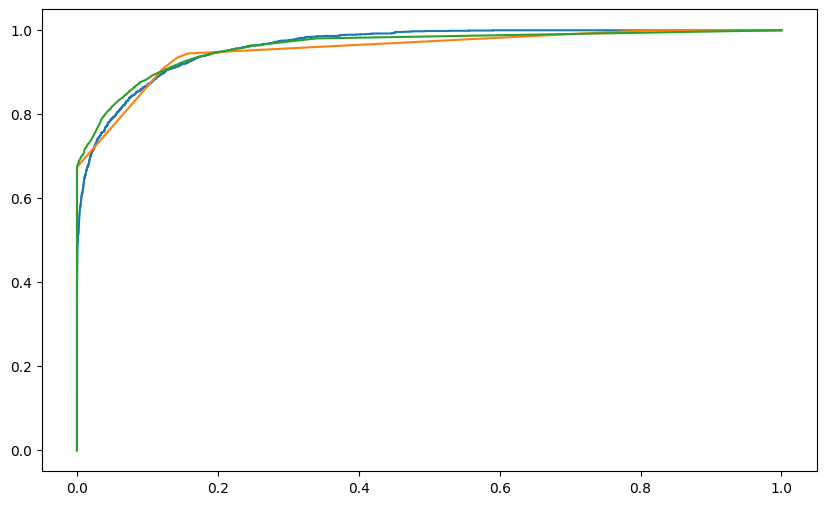

In [34]:
results = {}

plt.figure(figsize=(10,6))

for name, model in models.items():
    
    # Create full pipeline
    pipe = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"\n================ {name} ================")
    print("Accuracy:", acc)
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")


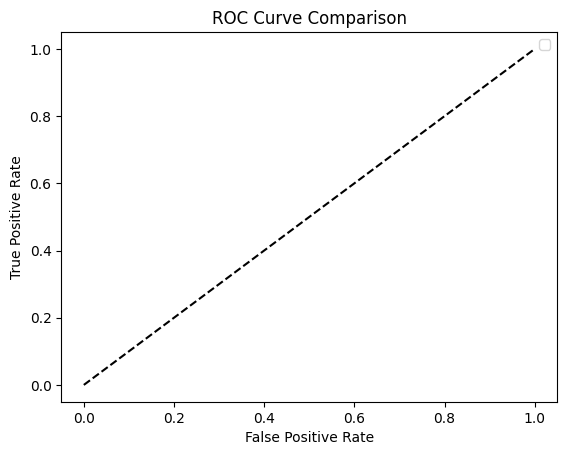

In [35]:
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [36]:
results_df = pd.DataFrame(list(results.items()), columns=['Model', 'Accuracy'])
results_df = results_df.sort_values(by='Accuracy', ascending=False)

print("\nFinal Model Comparison:\n")
print(results_df)



Final Model Comparison:

                 Model  Accuracy
1        Decision Tree   0.97230
2        Random Forest   0.97025
0  Logistic Regression   0.96045


In [37]:
best_model = results_df.iloc[0]
print(f"\nBest Model: {best_model['Model']} with Accuracy: {best_model['Accuracy']}")


Best Model: Decision Tree with Accuracy: 0.9723


## Thank you..pls upvote!!!!!!!